In [1]:
import matplotlib.pyplot as plt
import numpy as np

from emerald.numerics.adaptive_sampling import (
    AdaptiveSampler,
    ConstantMonitor,
    CurvatureMonitor,
    LogarithmicTailMonitor,
    SlopeMonitor,
    SuperGaussianMonitor,
)
from emerald.potentials import MorseSoftCoulomb


In [116]:
msc = MorseSoftCoulomb(alpha=0.01)

r_grid = np.linspace(-3*msc.alpha, 5000, int(1e7))

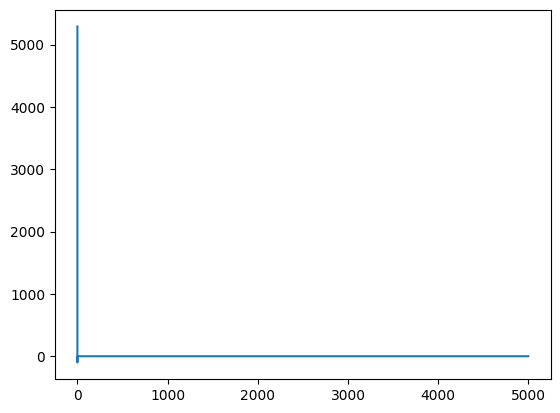

In [117]:
plt.plot(r_grid, msc(r_grid))

In [103]:
well_mom = SuperGaussianMonitor(sigma_L=msc.well_depth*2, sigma_R=msc.beta/2, p=4)
tail_mom = LogarithmicTailMonitor(L=0.1, lamda=msc.well_depth)
base_mom = ConstantMonitor(level=0.01)


In [5]:
1/msc.beta

0.14142135623730953

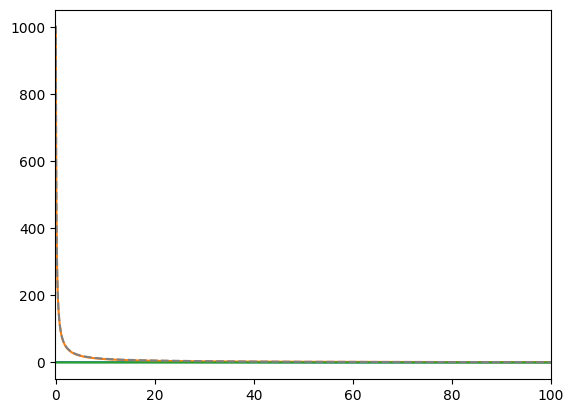

In [118]:
plt.plot(r_grid, well_mom(msc, r_grid))
plt.plot(r_grid, tail_mom(msc, r_grid))
plt.plot(r_grid, base_mom(msc, r_grid))
plt.xlim(-0.2, 100)

total_mom = well_mom + tail_mom + base_mom

plt.plot(r_grid, total_mom(msc, r_grid), ls='dashed', c='grey')

In [ ]:
curv_mom = CurvatureMonitor(lamda=2*msc.well_depth, baseline=0.01)
slop_mom = SlopeMonitor(lamda=msc.beta/10, baseline=0.01, p=1)
sampler = AdaptiveSampler(msc, r_grid[0], r_grid[-1], curv_mom+slop_mom, int(1e7))

/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/msc.py:33: RuntimeWarning: overflow encountered in exp
  morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/msc.py:33: RuntimeWarning: invalid value encountered in multiply
  morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/msc.py:41: RuntimeWarning: overflow encountered in exp
  morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )
/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/msc.py:41: RuntimeWarning: invalid value encountered in multiply
  morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )


In [121]:
sampler = AdaptiveSampler(msc, r_grid[0], r_grid[-1], total_mom, int(1e7))


In [9]:
msc.beta

7.071067811865474

In [10]:
msc.well_depth

10.0

In [122]:
samps = sampler.sample(500)

(-100.0, 100.0)

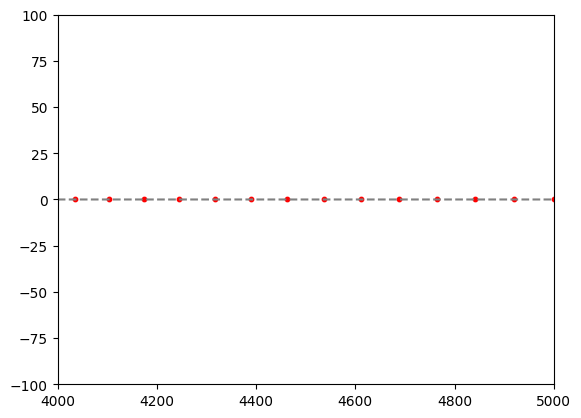

In [124]:
plt.plot(r_grid, msc(r_grid), ls='dashed', c='grey')
plt.scatter(samps, msc(samps), s=10, c='red')
# plt.xlim(10, 100)
plt.xlim(4000, 5000)
# plt.xlim(-0.2, 10)
# plt.xlim(-0.01, 0.1)
plt.ylim(-msc.well_depth, msc.well_depth)

(-0.2, 10.0)

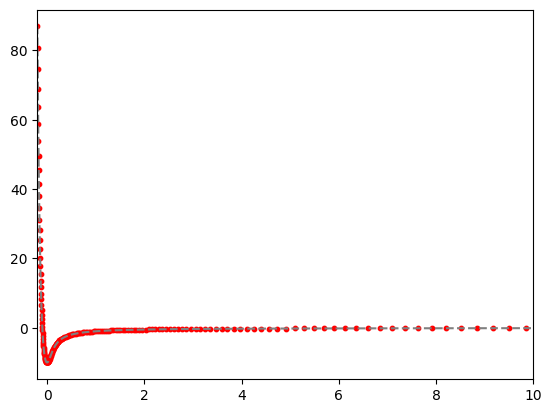

In [13]:
plt.plot(r_grid, msc(r_grid), ls='dashed', c='grey')
plt.scatter(samps, msc(samps), s=10, c='red')
# plt.xlim(10, 100)
plt.xlim(-0.2, 10)
# plt.xlim(-0.15, 1)

In [125]:
bps = samps

In [15]:
from emerald.quantum.representations import BSplineBasis, FourierGridBasis
from emerald.quantum.dynamics import Spectrum

In [57]:
fgh_grid = np.linspace(-0.3, 700, 8193)
msc_fourier = FourierGridBasis(fgh_grid)

In [126]:
msc_basis = BSplineBasis(bps, 9)

In [58]:
msc_spec_fourier = Spectrum.from_representation(msc_fourier, msc)

In [127]:
msc_spec = Spectrum.from_representation(msc_basis, msc, 'dirichlet', 'dirichlet')

In [20]:
# msc_spec_fourier.states = msc_spec_fourier.states*np.sqrt(msc_fourier.dr)

In [20]:
msc_spec.energies[:10]

array([-1.06360524, -0.17619413, -0.06937979, -0.03683044, -0.02278448,
       -0.01547326, -0.01118998, -0.00846713, -0.00662946, -0.00533106])

In [128]:
msc_spec.energies[:10]

array([-0.57543702, -0.13389673, -0.05814406, -0.03233235, -0.02055125,
       -0.01420679, -0.01040378, -0.00794603, -0.00626649, -0.00506819])

In [21]:
msc_spec_fourier.energies[:10]

array([-1.27150689, -0.19061173, -0.07328727, -0.03866085, -0.02411142,
       -0.01730998, -0.01416433, -0.01096852, -0.00841804, -0.00662106])

In [59]:
msc_spec_fourier.energies[:10]

array([-1.25666655, -0.18911834, -0.0726752 , -0.03819623, -0.02353566,
       -0.01599839, -0.01170335, -0.00940058, -0.00807814, -0.00655904])

In [27]:
pos_grid = np.linspace(-0.3, 100, 10000)

In [40]:
dr = msc_fourier.dr

In [63]:
msc_spec_fourier = msc_spec_fourier.truncate(500)

Hi
Hi


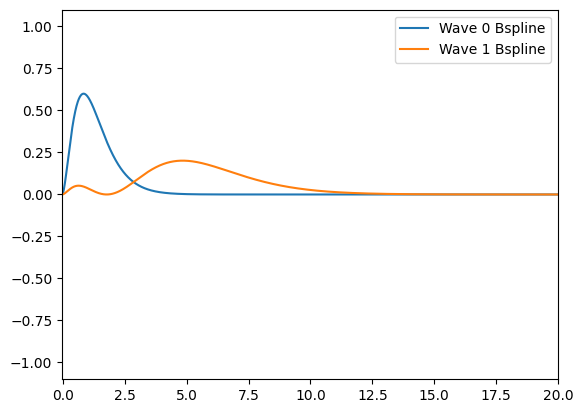

In [130]:
for i in range(2):
    plt.plot(pos_grid, msc_spec.wavefunction(i)(pos_grid)**2, label=f"Wave {i} Bspline")
    # plt.plot(pos_grid, msc_spec_fourier.wavefunction(i)(pos_grid), label=f"Wave {i} FGH")

plt.xlim(-3*msc.alpha, 20)
plt.ylim(-1.1, 1.1)
plt.legend()

In [78]:
np.sum(msc_spec_fourier.wavefunction(0)(np.linspace(-0.3, 700, 8193))**2)*dr

0.9754052072921134

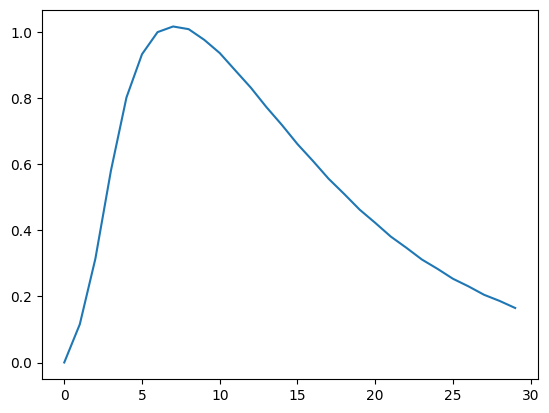

In [42]:
plt.plot(msc_spec_fourier.states[:30, 0])

In [72]:
np.sum(msc_spec_fourier.states[:, 0]**2)*dr

0.9754052072921134

In [30]:
msc_fourier.dr**(1/2)

0.44725831462366356

In [131]:
np.trapz(msc_spec.wavefunction(0)(r_grid)**2, r_grid)

Hi


0.9999999999999998